# Detecção de Anomalias em Redes Corporativas

**Equipamentos integrados com o Zabbix:**
- 1 MikroTik HEX RB750Gr3 (gateway)
- 1 Ubiquiti UniFi U6+ (access points)
- 1 Ubiquiti UniFi U6+ (access points)

** **

**10 métricas monitoradas pelo Zabbix:**

| Dispositivo | Métricas |
|---|---|
| MikroTik | CPU, memória, tráfego WAN, latência ICMP |
| UniFi AP-01 | CPU, clientes conectados, tráfego wireless |
| UniFi AP-02 | CPU, clientes conectados, tráfego wireless |

** **

**Tem 3 problemas de exemplo:**
1. **Dia corporativo típico** — falhas e picos operacionais
2. **Sob ataque** — DDoS, port scan, abuse de guest
3. **Degradação gradual** — saturação progressiva, memory leak


In [188]:
import os
import csv
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics       import precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow       import keras
from tensorflow.keras import layers

# botão de salvar
import ipywidgets as widgets
from IPython.display import display, clear_output

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 1. Sumário do que alterar no proximo bloco
** **

| CENARIO | 1, 2 ou 3 |
   
   OU

Se tiver um csv para ler, altere o CSV_PATH, exemplo: '/content/nome do seu csv.csv'. E DEIXE O NUMERO DO CENARIO, ELE IRÁ SER IGNORADO.

** **  

| DIAS | Quantos dias gerar OU  quantos dias sua coleta tem |

** **

| CSV_PATH | Caminho do seu CSV real (`None` = usa cenário gerado) |

** **

In [189]:

CENARIO = 2

# None = gera o cenario simulado acima
CSV_PATH = None    # ex: '/content/SEU CSV AQUI.csv'
#ALTERE OS DIAS CONFORME COLETOU NO SEU ZABBIX
DIAS            = 3


WINDOW          = 30
THRESHOLD_SIGMA = 3


DATA_DIR = 'data'
RES_DIR  = 'resultados'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RES_DIR,  exist_ok=True)

# modelos exemplos
CENARIOS = {
    1: 'dia_corporativo',
    2: 'sob_ataque',
    3: 'degradacao_gradual',
}

print(f'Dias: {DIAS} | Janela: {WINDOW} min | Sigma: {THRESHOLD_SIGMA}')


Dias: 3 | Janela: 30 min | Sigma: 3


## 2. Geração dos 3 cenários de exemplo

Esta célula cria 3 CSVs no formato consolidado do Zabbix:
- `data/cenario1_dia_corporativo.csv`
- `data/cenario2_sob_ataque.csv`
- `data/cenario3_degradacao_gradual.csv`

Cada um simula 3 dias de telemetria do dos mesmos equipamentos (1 MikroTik + 2 UniFi), com tipos de anomalia diferentes. Roda só uma vez, depois, muda o CENARIO no bloco anterior.

In [190]:

# Padrao diario base (sinusoide com pico em torno das 15h)

def padrao_diario(min_do_dia, base, amplitude, pico_hora=15):
    pico_min = pico_hora * 60
    fase = 2 * np.pi * (min_do_dia - pico_min) / 1440
    return base + amplitude * (1 + np.cos(fase)) / 2


# Base da série - uso normal

def gerar_baseline(N, timestamps):
    minuto = np.array([(t.hour * 60 + t.minute) for t in timestamps])

    # MikroTik HEX RB750Gr3 — router pequeno
    mk_cpu          = padrao_diario(minuto, base=8,  amplitude=18, pico_hora=15) + np.random.normal(0, 2, N)
    mk_mem          = 45 + np.random.normal(0, 3, N)
    mk_wan_mbps     = padrao_diario(minuto, base=10, amplitude=140, pico_hora=15) + np.random.normal(0, 12, N)
    mk_icmp_latency = padrao_diario(minuto, base=6,  amplitude=4,  pico_hora=16) + np.random.normal(0, 1, N)

    # UniFi U6+ AP-01
    ap1_cpu             = padrao_diario(minuto, base=15, amplitude=20, pico_hora=15) + np.random.normal(0, 2, N)
    ap1_clients         = padrao_diario(minuto, base=3,  amplitude=50, pico_hora=15) + np.random.normal(0, 2, N)
    ap1_traffic_mbps    = padrao_diario(minuto, base=5,  amplitude=90, pico_hora=15) + np.random.normal(0, 8, N)

    # UniFi U6+ AP-02 (ligeiramente menor que AP-01)
    ap2_cpu             = padrao_diario(minuto, base=12, amplitude=22, pico_hora=15) + np.random.normal(0, 2, N)
    ap2_clients         = padrao_diario(minuto, base=3,  amplitude=45, pico_hora=15) + np.random.normal(0, 2, N)
    ap2_traffic_mbps    = padrao_diario(minuto, base=4,  amplitude=75, pico_hora=15) + np.random.normal(0, 8, N)

    return {
        'mk_cpu':            mk_cpu,
        'mk_mem':            mk_mem,
        'mk_wan_mbps':       mk_wan_mbps,
        'mk_icmp_latency':   mk_icmp_latency,
        'ap1_cpu':           ap1_cpu,
        'ap1_clients':       ap1_clients,
        'ap1_traffic_mbps':  ap1_traffic_mbps,
        'ap2_cpu':           ap2_cpu,
        'ap2_clients':       ap2_clients,
        'ap2_traffic_mbps':  ap2_traffic_mbps,
    }


def aplicar_evento(series_dict, start_idx, duracao, modificacoes, anomaly_flag, descricao=''):
    """Aplica `modificacoes` (dict de col -> funcao_de_valor) num intervalo."""
    end_idx = start_idx + duracao
    for col, fn in modificacoes.items():
        series_dict[col][start_idx:end_idx] = fn(series_dict[col][start_idx:end_idx])
    anomaly_flag[start_idx:end_idx] = 1
    return {'start': start_idx, 'end': end_idx, 'descricao': descricao}

# CENARIO 1 - Muitos Usos

def gerar_cenario_1(series, anom):
    eventos = []
    # Dia 1, 09:00 (15 min) — AP-01 trava
    eventos.append(aplicar_evento(series, (0*24+9)*60, 15, {
        'ap1_cpu':           lambda v: np.zeros_like(v),
        'ap1_clients':       lambda v: np.zeros_like(v),
        'ap1_traffic_mbps':  lambda v: np.zeros_like(v),
    }, anom, 'AP-01 travado / desligado'))

    # Dia 1, 18:00 (10 min) — pico AP-02
    eventos.append(aplicar_evento(series, (0*24+18)*60, 10, {
        'ap2_clients':       lambda v: np.clip(v + 80, 0, 200),
        'ap2_cpu':           lambda v: np.clip(v + 50, 0, 100),
        'ap2_traffic_mbps':  lambda v: np.clip(v + 200, 0, 350),
    }, anom, 'Pico de uso no AP-02'))

    # Dia 2, 04:00 (15 min) — latencia ISP
    eventos.append(aplicar_evento(series, (1*24+4)*60, 15, {
        'mk_icmp_latency':   lambda v: np.full_like(v, 280.0) + np.random.normal(0, 15, len(v)),
    }, anom, 'Latencia alta no link WAN (ISP)'))

    # Dia 2, 22:00 (20 min) — pico AP-01 noturno (anomalo)
    eventos.append(aplicar_evento(series, (1*24+22)*60, 20, {
        'ap1_clients':       lambda v: np.clip(v + 90, 0, 200),
        'ap1_cpu':           lambda v: np.clip(v + 55, 0, 100),
        'ap1_traffic_mbps':  lambda v: np.clip(v + 180, 0, 300),
    }, anom, 'Pico noturno anomalo no AP-01'))

    # Dia 3, 12:00 (20 min) — AP-02 trava
    eventos.append(aplicar_evento(series, (2*24+12)*60, 20, {
        'ap2_cpu':           lambda v: np.zeros_like(v),
        'ap2_clients':       lambda v: np.zeros_like(v),
        'ap2_traffic_mbps':  lambda v: np.zeros_like(v),
    }, anom, 'AP-02 travado em horario comercial'))

    # Dia 3, 16:00 (12 min) — sobrecarga AP-01
    eventos.append(aplicar_evento(series, (2*24+16)*60, 12, {
        'ap1_cpu':           lambda v: np.full_like(v, 92.0) + np.random.normal(0, 2, len(v)),
    }, anom, 'CPU AP-01 sobrecarregada'))

    return eventos



# CENARIO 2 — Ataque na rede

def gerar_cenario_2(series, anom):
    eventos = []
    # Dia 1, 03:00 (20 min) — DDoS noturno
    eventos.append(aplicar_evento(series, (0*24+3)*60, 20, {
        'mk_wan_mbps':       lambda v: np.full_like(v, 920.0) + np.random.normal(0, 15, len(v)),
        'mk_cpu':            lambda v: np.clip(v + 75, 0, 100),
        'mk_icmp_latency':   lambda v: np.full_like(v, 220.0) + np.random.normal(0, 12, len(v)),
    }, anom, 'DDoS noturno na WAN'))

    # Dia 1, 14:00 (15 min) — port scan
    eventos.append(aplicar_evento(series, (0*24+14)*60, 15, {
        'mk_icmp_latency':   lambda v: np.full_like(v, 120.0) + np.random.normal(0, 8, len(v)),
        'mk_cpu':            lambda v: np.clip(v + 35, 0, 100),
        'ap1_cpu':           lambda v: np.clip(v + 30, 0, 100),
        'ap2_cpu':           lambda v: np.clip(v + 30, 0, 100),
    }, anom, 'Port scan / nmap'))

    # Dia 2, 02:00 (25 min) — guest abuse AP-02
    eventos.append(aplicar_evento(series, (1*24+2)*60, 25, {
        'ap2_clients':       lambda v: np.full_like(v, 180.0) + np.random.normal(0, 5, len(v)),
        'ap2_traffic_mbps':  lambda v: np.full_like(v, 320.0) + np.random.normal(0, 10, len(v)),
        'ap2_cpu':           lambda v: np.full_like(v, 88.0)  + np.random.normal(0, 3, len(v)),
    }, anom, 'Guest abuse / clientes anomalos no AP-02'))

    # Dia 2, 19:00 (20 min) — DDoS comercial
    eventos.append(aplicar_evento(series, (1*24+19)*60, 20, {
        'mk_wan_mbps':       lambda v: np.full_like(v, 960.0) + np.random.normal(0, 15, len(v)),
        'mk_cpu':            lambda v: np.clip(v + 60, 0, 100),
        'mk_icmp_latency':   lambda v: np.full_like(v, 300.0) + np.random.normal(0, 20, len(v)),
    }, anom, 'DDoS em horario comercial'))

    # Dia 3, 09:00 (15 min) — port scan manha
    eventos.append(aplicar_evento(series, (2*24+9)*60, 15, {
        'mk_icmp_latency':   lambda v: np.full_like(v, 95.0) + np.random.normal(0, 6, len(v)),
        'mk_cpu':            lambda v: np.clip(v + 30, 0, 100),
    }, anom, 'Port scan matutino'))

    # Dia 3, 22:00 (30 min) — DDoS sustentado
    eventos.append(aplicar_evento(series, (2*24+22)*60, 30, {
        'mk_wan_mbps':       lambda v: np.full_like(v, 980.0) + np.random.normal(0, 10, len(v)),
        'mk_cpu':            lambda v: np.clip(v + 70, 0, 100),
        'mk_icmp_latency':   lambda v: np.full_like(v, 280.0) + np.random.normal(0, 25, len(v)),
        'ap1_cpu':           lambda v: np.clip(v + 40, 0, 100),
        'ap2_cpu':           lambda v: np.clip(v + 40, 0, 100),
    }, anom, 'DDoS sustentado'))

    return eventos


# CENARIO 3 — Degradacao gradual

def gerar_cenario_3(series, anom):
    eventos = []

    def rampa(start_val, end_val, length, noise_std=2):
        return np.linspace(start_val, end_val, length) + np.random.normal(0, noise_std, length)

    # Dia 1, 10:00-12:00 (120 min) — crescimento clientes AP-01
    s, d = (0*24+10)*60, 120
    eventos.append(aplicar_evento(series, s, d, {
        'ap1_clients':       lambda v: rampa(20, 120, len(v), 2),
        'ap1_cpu':           lambda v: rampa(25, 75,  len(v), 2),
        'ap1_traffic_mbps':  lambda v: rampa(40, 180, len(v), 5),
    }, anom, 'Crescimento progressivo de clientes no AP-01'))

    # Dia 2, 16:00-18:00 (120 min) — memory leak AP-02
    s, d = (1*24+16)*60, 120
    eventos.append(aplicar_evento(series, s, d, {
        'ap2_cpu':           lambda v: rampa(30, 88, len(v), 2),
    }, anom, 'Memory leak no AP-02 (CPU sobe gradualmente)'))

    # Dia 3, 09:00-11:00 (120 min) — saturacao WAN
    s, d = (2*24+9)*60, 120
    eventos.append(aplicar_evento(series, s, d, {
        'mk_wan_mbps':       lambda v: rampa(150, 850, len(v), 15),
        'mk_icmp_latency':   lambda v: rampa(10,   75, len(v), 2),
        'mk_cpu':            lambda v: rampa(15,   60, len(v), 2),
    }, anom, 'Saturacao gradual do enlace WAN'))

    # Dia 3, 19:00-21:00 (120 min) — crescimento clientes AP-02
    s, d = (2*24+19)*60, 120
    eventos.append(aplicar_evento(series, s, d, {
        'ap2_clients':       lambda v: rampa(15, 110, len(v), 2),
        'ap2_cpu':           lambda v: rampa(20, 78,  len(v), 2),
        'ap2_traffic_mbps':  lambda v: rampa(30, 170, len(v), 5),
    }, anom, 'Crescimento progressivo de clientes no AP-02'))

    return eventos


def salvar_cenario(nome, gerador_eventos, N, timestamps):
    np.random.seed(42 + hash(nome) % 100)
    series = gerar_baseline(N, timestamps)
    anom   = np.zeros(N, dtype=int)

    eventos = gerador_eventos(series, anom)

    # Clips realistas
    series['mk_cpu']           = np.clip(series['mk_cpu'],           0, 100)
    series['mk_mem']           = np.clip(series['mk_mem'],           0, 100)
    series['mk_wan_mbps']      = np.clip(series['mk_wan_mbps'],      0, 1000)
    series['mk_icmp_latency']  = np.clip(series['mk_icmp_latency'],  0.5, 1000)
    series['ap1_cpu']          = np.clip(series['ap1_cpu'],          0, 100)
    series['ap1_clients']      = np.clip(series['ap1_clients'],      0, 250).astype(int)
    series['ap1_traffic_mbps'] = np.clip(series['ap1_traffic_mbps'], 0, 500)
    series['ap2_cpu']          = np.clip(series['ap2_cpu'],          0, 100)
    series['ap2_clients']      = np.clip(series['ap2_clients'],      0, 250).astype(int)
    series['ap2_traffic_mbps'] = np.clip(series['ap2_traffic_mbps'], 0, 500)

    df = pd.DataFrame({'timestamp': timestamps, **series, 'anomaly': anom})
    path = f'{DATA_DIR}/cenario_{nome}.csv'
    df.to_csv(path, index=False)

    print(f'  -> {path}  ({N} amostras, {anom.sum()} anomalas, {len(eventos)} eventos)')
    return df, eventos


N          = DIAS * 24 * 60
start_time = datetime(2025, 5, 19, 0, 0, 0)
timestamps = [start_time + timedelta(minutes=i) for i in range(N)]

print('Gerando os 3 cenarios de exemplo...')
df1, ev1 = salvar_cenario('dia_corporativo',    gerar_cenario_1, N, timestamps)
df2, ev2 = salvar_cenario('sob_ataque',         gerar_cenario_2, N, timestamps)
df3, ev3 = salvar_cenario('degradacao_gradual', gerar_cenario_3, N, timestamps)

print(f'\nPronto! Os 3 CSVs estao em {DATA_DIR}/')


Gerando os 3 cenarios de exemplo...
  -> data/cenario_dia_corporativo.csv  (4320 amostras, 92 anomalas, 6 eventos)
  -> data/cenario_sob_ataque.csv  (4320 amostras, 125 anomalas, 6 eventos)
  -> data/cenario_degradacao_gradual.csv  (4320 amostras, 480 anomalas, 4 eventos)

Pronto! Os 3 CSVs estao em data/


In [191]:
if CSV_PATH is not None:
    csv_alvo = CSV_PATH
    nome_cenario = 'csv_real'
else:
    nome_cenario = CENARIOS[CENARIO]
    csv_alvo = f'{DATA_DIR}/cenario_{nome_cenario}.csv'

print(f'Carregando: {csv_alvo}')
df = pd.read_csv(csv_alvo, parse_dates=['timestamp'])

# Identifica as colunas de metricas (todas exceto timestamp e anomaly)
FEATURES = [c for c in df.columns if c not in ('timestamp', 'anomaly')]
print(f'Metricas detectadas ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  - {f}')

print(f'\nTotal: {len(df)} amostras | Anomalias rotuladas: {df.get("anomaly", pd.Series([0])).sum()}')
df.head()


Carregando: data/cenario_sob_ataque.csv
Metricas detectadas (10):
  - mk_cpu
  - mk_mem
  - mk_wan_mbps
  - mk_icmp_latency
  - ap1_cpu
  - ap1_clients
  - ap1_traffic_mbps
  - ap2_cpu
  - ap2_clients
  - ap2_traffic_mbps

Total: 4320 amostras | Anomalias rotuladas: 125


,timestamp,mk_cpu,mk_mem,mk_wan_mbps,mk_icmp_latency,ap1_cpu,ap1_clients,ap1_traffic_mbps,ap2_cpu,ap2_clients,ap2_traffic_mbps,anomaly
0,2025-05-19 00:00:00,11.273130,46.314122,40.208333,6.378664,17.228346,13,10.843615,17.274160,11,26.900292,0
1,2025-05-19 00:01:00,9.249213,46.026002,35.058864,6.910700,19.757640,6,20.311607,14.754387,12,1.032826,0
2,2025-05-19 00:02:00,6.163969,44.029877,42.098647,6.576341,21.181861,10,32.084813,13.701887,9,27.421156,0
3,2025-05-19 00:03:00,11.733763,47.818527,21.854137,7.193047,20.434735,11,7.679367,19.913780,9,12.754906,0
4,2025-05-19 00:04:00,13.875474,46.854365,25.753433,7.893803,17.669142,13,0.000000,15.095477,7,21.374164,0


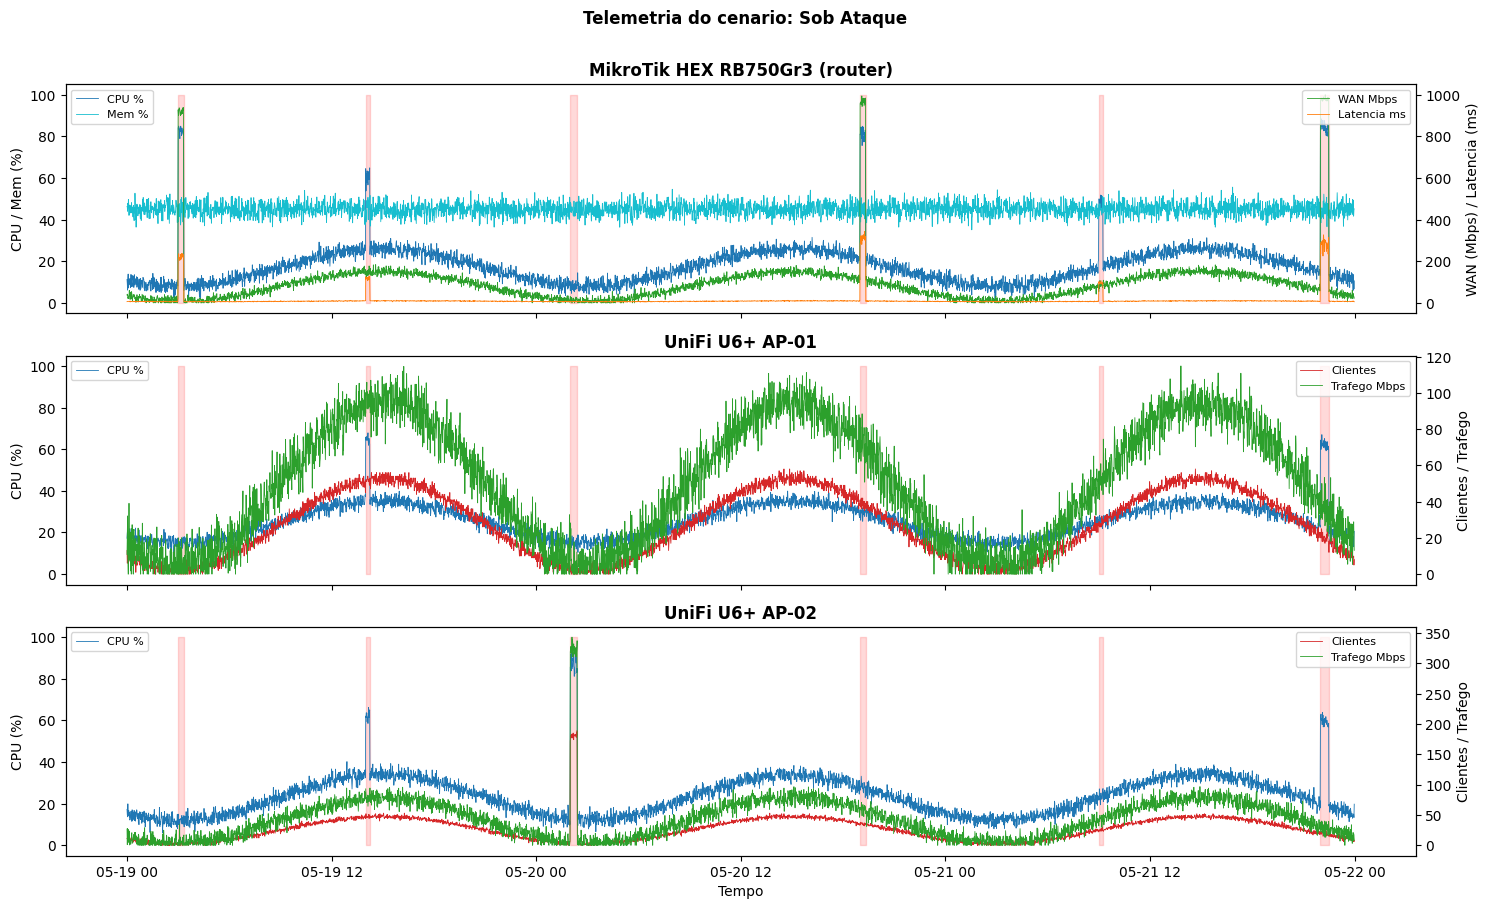

In [192]:
# Grafico panoramico — uma linha por dispositivo
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
anom_mask = df['anomaly'].astype(bool).values if 'anomaly' in df.columns else np.zeros(len(df), dtype=bool)
ts = df['timestamp'].values

# Painel 1: MikroTik
ax = axes[0]
ax.plot(ts, df['mk_cpu'],          color='tab:blue',   linewidth=0.6, label='CPU %')
ax.plot(ts, df['mk_mem'],          color='tab:cyan',   linewidth=0.6, label='Mem %')
ax2 = ax.twinx()
ax2.plot(ts, df['mk_wan_mbps'],    color='tab:green',  linewidth=0.6, label='WAN Mbps')
ax2.plot(ts, df['mk_icmp_latency'],color='tab:orange', linewidth=0.6, label='Latencia ms')
ax.fill_between(ts, 0, 100, where=anom_mask, alpha=0.15, color='red')
ax.set_ylabel('CPU / Mem (%)')
ax2.set_ylabel('WAN (Mbps) / Latencia (ms)')
ax.set_title('MikroTik HEX RB750Gr3 (router)', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# Painel 2: AP-01
ax = axes[1]
ax.plot(ts, df['ap1_cpu'],            color='tab:blue',  linewidth=0.6, label='CPU %')
ax2 = ax.twinx()
ax2.plot(ts, df['ap1_clients'],       color='tab:red',   linewidth=0.6, label='Clientes')
ax2.plot(ts, df['ap1_traffic_mbps'],  color='tab:green', linewidth=0.6, label='Trafego Mbps')
ax.fill_between(ts, 0, 100, where=anom_mask, alpha=0.15, color='red')
ax.set_ylabel('CPU (%)')
ax2.set_ylabel('Clientes / Trafego')
ax.set_title('UniFi U6+ AP-01', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# Painel 3: AP-02
ax = axes[2]
ax.plot(ts, df['ap2_cpu'],            color='tab:blue',  linewidth=0.6, label='CPU %')
ax2 = ax.twinx()
ax2.plot(ts, df['ap2_clients'],       color='tab:red',   linewidth=0.6, label='Clientes')
ax2.plot(ts, df['ap2_traffic_mbps'],  color='tab:green', linewidth=0.6, label='Trafego Mbps')
ax.fill_between(ts, 0, 100, where=anom_mask, alpha=0.15, color='red')
ax.set_ylabel('CPU (%)')
ax2.set_ylabel('Clientes / Trafego')
ax.set_title('UniFi U6+ AP-02', fontweight='bold')
ax.set_xlabel('Tempo')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Telemetria do cenario: {nome_cenario.replace("_", " ").title()}', fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()


## 3. Pré-processamento

Split temporal 60/20/20

normalização MinMax - ajustada apenas com amostras normais

janela de 30 minutos para o LSTM.

In [193]:
# Treino aprende o padrao 'normal' — descontamina anomalias na hora de ajustar o scaler
X = df[FEATURES].values.astype('float32')
y = df['anomaly'].values if 'anomaly' in df.columns else np.zeros(len(df), dtype=int)
ts_all = df['timestamp'].values

i_train = int(len(df) * 0.6)
i_val   = int(len(df) * 0.8)

X_train, X_val, X_test = X[:i_train], X[i_train:i_val], X[i_val:]
y_train, y_val, y_test = y[:i_train], y[i_train:i_val], y[i_val:]
ts_test = ts_all[i_val:]

print(f'Splits: treino={len(X_train)} | val={len(X_val)} | teste={len(X_test)}')
print(f'Anomalias: treino={y_train.sum()} | val={y_val.sum()} | teste={y_test.sum()}')

scaler = MinMaxScaler()
scaler.fit(X_train[y_train == 0])

X_train_n = scaler.transform(X_train)
X_val_n   = scaler.transform(X_val)
X_test_n  = scaler.transform(X_test)

def make_sequences(Xn, y, W):
    Xs, ys, lbls, idxs = [], [], [], []
    for i in range(len(Xn) - W):
        Xs.append(Xn[i:i+W])
        ys.append(Xn[i+W])
        lbls.append(y[i+W])
        idxs.append(i+W)
    return (np.array(Xs, dtype='float32'),
            np.array(ys, dtype='float32'),
            np.array(lbls), np.array(idxs))

Xw_train, yw_train, lbl_train, idx_train = make_sequences(X_train_n, y_train, WINDOW)
Xw_val,   yw_val,   lbl_val,   idx_val   = make_sequences(X_val_n,   y_val,   WINDOW)
Xw_test,  yw_test,  lbl_test,  idx_test  = make_sequences(X_test_n,  y_test,  WINDOW)


def normal_window_mask(y_arr, idx_arr, W):
    return np.array([y_arr[i-W:i+1].sum() == 0 for i in idx_arr])

mask_train_normal = normal_window_mask(y_train, idx_train, WINDOW)
Xw_train_clean = Xw_train[mask_train_normal]
yw_train_clean = yw_train[mask_train_normal]
print(f'Janelas limpas para treino: {mask_train_normal.sum()} / {len(mask_train_normal)}')


Splits: treino=2592 | val=864 | teste=864
Anomalias: treino=72 | val=23 | teste=30
Janelas limpas para treino: 2400 / 2562


## 4. Modelo LSTM

In [194]:
n_feat = len(FEATURES)
model = keras.Sequential([
    layers.Input(shape=(WINDOW, n_feat)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(n_feat),
], name='lstm_forecaster_v4')

model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
model.summary()


Model: "lstm_forecaster_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,946 (124.79 KB)

 Trainable params: 31,946 (124.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
34/34 - 5s - 133ms/step - loss: 0.0683 - val_loss: 0.0101
Epoch 2/30
34/34 - 1s - 41ms/step - loss: 0.0248 - val_loss: 0.0083
Epoch 3/30
34/34 - 2s - 67ms/step - loss: 0.0214 - val_loss: 0.0086
Epoch 4/30
34/34 - 1s - 33ms/step - loss: 0.0189 - val_loss: 0.0098
Epoch 5/30
34/34 - 2s - 49ms/step - loss: 0.0177 - val_loss: 0.0072
Epoch 6/30
34/34 - 2s - 61ms/step - loss: 0.0166 - val_loss: 0.0072
Epoch 7/30
34/34 - 2s - 47ms/step - loss: 0.0150 - val_loss: 0.0083
Epoch 8/30
34/34 - 1s - 34ms/step - loss: 0.0148 - val_loss: 0.0079
Epoch 9/30
34/34 - 1s - 37ms/step - loss: 0.0139 - val_loss: 0.0071
Epoch 10/30
34/34 - 1s - 33ms/step - loss: 0.0135 - val_loss: 0.0071
Epoch 11/30
34/34 - 1s - 34ms/step - loss: 0.0127 - val_loss: 0.0085
Epoch 12/30
34/34 - 1s - 34ms/step - loss: 0.0122 - val_loss: 0.0074
Epoch 13/30
34/34 - 1s - 37ms/step - loss: 0.0118 - val_loss: 0.0096
Epoch 14/30
34/34 - 1s - 33ms/step - loss: 0.0116 - val_loss: 0.0073
Epoch 15/30
34/34 - 2s - 50ms/step - loss:

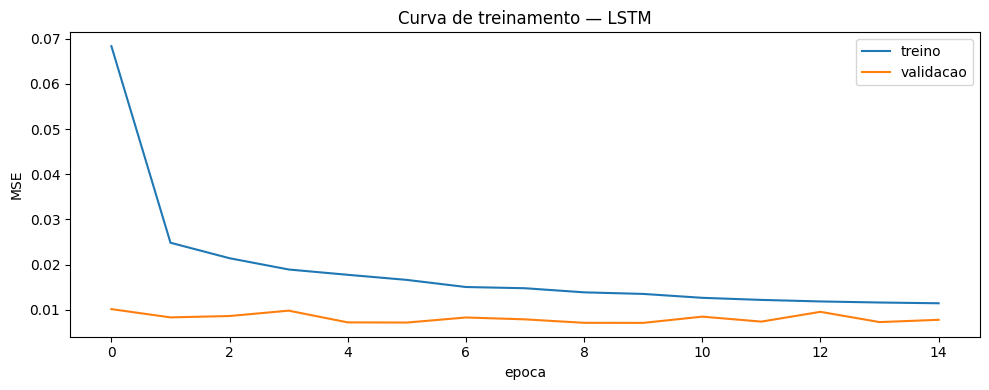

In [182]:
history = model.fit(
    Xw_train_clean, yw_train_clean,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='treino')
plt.plot(history.history['val_loss'], label='validacao')
plt.xlabel('epoca'); plt.ylabel('MSE'); plt.legend()
plt.title('Curva de treinamento — LSTM')
plt.tight_layout()
plt.show()


In [183]:
pred_val  = model.predict(Xw_val,  verbose=0)
pred_test = model.predict(Xw_test, verbose=0)

err_val  = np.mean((pred_val  - yw_val)  ** 2, axis=1)
err_test = np.mean((pred_test - yw_test) ** 2, axis=1)

def smooth(x, k=5):
    return pd.Series(x).rolling(k, min_periods=1).mean().values

err_val_s  = smooth(err_val)
err_test_s = smooth(err_test)

mask_val_normal = normal_window_mask(y_val, idx_val, WINDOW)
err_val_normal  = err_val_s[mask_val_normal]
threshold = float(np.mean(err_val_normal) + THRESHOLD_SIGMA * np.std(err_val_normal))
print(f'Threshold dinamico: {threshold:.6f}')

pred_lstm = (err_test_s > threshold).astype(int)
print(f'Janelas anomalas detectadas no teste: {pred_lstm.sum()} / {len(pred_lstm)}')


Threshold dinamico: 0.013116
Janelas anomalas detectadas no teste: 48 / 834


## 5. Motor de Diagnóstico — por dispositivo

Agora que temos 3 dispositivos, o motor identifica **qual deles** está com problema (MikroTik, AP-01 ou AP-02) e aplica as regras heurísticas considerando o perfil de cada um.

**Ordem das regras** (primeira que bater vence):

1. **Falha de equipamento** — CPU de algum dispositivo < 1 %
2. **Ataque / flood** — latência E tráfego/perda altos simultâneos
3. **Loopback / broadcast storm** — só latência alta, sem perda
4. **Degradação gradual** — métricas crescendo ao longo de várias janelas
5. **Alta utilização** — CPU ou clientes acima de μ+2σ num dispositivo
6. **Anomalia indefinida** — nenhuma regra satisfeita

In [184]:
# Junta as colunas por dispositivos
DEVICES = {
    'MikroTik (RB750Gr3)': ['mk_cpu', 'mk_mem', 'mk_wan_mbps', 'mk_icmp_latency'],
    'UniFi AP-01 (U6+)':   ['ap1_cpu', 'ap1_clients', 'ap1_traffic_mbps'],
    'UniFi AP-02 (U6+)':   ['ap2_cpu', 'ap2_clients', 'ap2_traffic_mbps'],
}

# Mapeia cada metrica ao tipo logico (cpu / latencia / trafego / clientes)
def tipo_metrica(col):
    cl = col.lower()
    if 'cpu' in cl:                                                                   return 'cpu'
    if 'mem' in cl:                                                                   return 'mem'
    if any(k in cl for k in ['latenc','ping','rtt','delay']):                         return 'latencia'
    if any(k in cl for k in ['wan','traffic','mbps']) and 'latenc' not in cl:         return 'trafego'
    if 'client' in cl:                                                                return 'clientes'
    return 'outro'


DIAGNOSTICOS = {
    'Falha de equipamento': {
        'cor': '#e74c3c', 'severidade': 'CRITICO',
        'causas': [
            'AP desligado, sem energia ou travado',
            'Cabo de rede desconectado fisicamente',
            'Reinicializacao nao programada',
            'Falha de hardware (fonte, placa de rede)',
        ],
        'acao': 'Verificar alimentacao e presenca fisica do equipamento.',
    },
    'Ataque / flood de rede': {
        'cor': '#e67e22', 'severidade': 'ALTO',
        'causas': [
            'DDoS ou flood de pacotes',
            'Varredura de portas (nmap / port scan)',
            'Numero de usuarios MUITO acima do padrao (guest abuse)',
            'ARP spoofing na rede local',
        ],
        'acao': 'Verificar logs do firewall e rastrear IP de origem.',
    },
    'Loopback / broadcast storm': {
        'cor': '#c0392b', 'severidade': 'ALTO',
        'causas': [
            'Loop fisico em switch (sem Spanning Tree ativo)',
            'DHCP propagando em loop — broadcast storm',
            'APIPA ativo — cliente sem DHCP (169.254.x.x)',
            'STP reconvergindo apos mudanca de topologia',
        ],
        'acao': 'Checar portas do switch, STP e servidor DHCP.',
    },
    'Degradacao gradual': {
        'cor': '#8e44ad', 'severidade': 'MEDIO',
        'causas': [
            'Enlace saturando progressivamente',
            'Crescimento anomalo de clientes conectados',
            'Interferencia de canal Wi-Fi',
            'Vazamento de memoria (memory leak) no firmware',
        ],
        'acao': 'Monitorar tendencia. Considerar balanceamento de carga.',
    },
    'Alta utilizacao de recursos': {
        'cor': '#d35400', 'severidade': 'MEDIO',
        'causas': [
            'Muitos usuarios conectados ao mesmo tempo',
            'Processo interno consumindo CPU (cron, backup)',
            'Firmware com vazamento de recursos',
            'Pico de uso legitimo (horario nobre)',
        ],
        'acao': 'Verificar clientes associados e processos rodando.',
    },
    'Anomalia indefinida': {
        'cor': '#7f8c8d', 'severidade': 'BAIXO',
        'causas': [
            'Causa nao identificada pelas regras atuais',
            'Evento atipico sem padrao claro',
            'Possivel falso positivo do modelo',
        ],
        'acao': 'Analise manual recomendada — verificar logs do Zabbix.',
    },
}


X_train_orig  = scaler.inverse_transform(Xw_train_clean[:, -1, :])
train_df_orig = pd.DataFrame(X_train_orig, columns=FEATURES)
baseline_mean = train_df_orig.mean()
baseline_std  = train_df_orig.std()

# Anomalias detectadas em escala original
anomaly_indices      = np.where(pred_lstm)[0]
anomaly_windows_orig = scaler.inverse_transform(
    Xw_test[anomaly_indices].reshape(-1, len(FEATURES))
).reshape(len(anomaly_indices), WINDOW, len(FEATURES))
anomaly_means_df = pd.DataFrame(anomaly_windows_orig.mean(axis=1), columns=FEATURES)

def has_upward_trend(vals, min_consec=3):
    count = 1
    for i in range(1, len(vals)):
        count = count + 1 if vals[i] > vals[i-1] else 1
        if count >= min_consec:
            return True
    return False


def diagnosticar_dispositivo(device_name, cols, row, i, anomaly_means_df):
    """Aplica as regras pra um unico dispositivo. Retorna tipo (ou None)."""
    # Mapeia colunas por tipo logico dentro deste dispositivo
    cpu_c  = [c for c in cols if tipo_metrica(c) == 'cpu']
    lat_c  = [c for c in cols if tipo_metrica(c) == 'latencia']
    tr_c   = [c for c in cols if tipo_metrica(c) == 'trafego']
    cli_c  = [c for c in cols if tipo_metrica(c) == 'clientes']

    # Regra 1: CPU proxima de zero
    if cpu_c:
        cpu_val = row[cpu_c].mean()
        if cpu_val < 1.0:
            return 'Falha de equipamento'

    # Limiares por metrica deste dispositivo
    def th(cols, sigma):
        if not cols: return None
        return float(baseline_mean[cols].mean() + sigma * baseline_std[cols].mean())

    th_lat_atk  = th(lat_c, 3)
    th_lat_soft = th(lat_c, 2)
    th_tr_atk   = th(tr_c,  3)
    th_cli_atk  = th(cli_c, 3)
    th_cpu_high = th(cpu_c, 2)

    lat_val = row[lat_c].mean() if lat_c else None
    tr_val  = row[tr_c].mean()  if tr_c  else None
    cli_val = row[cli_c].mean() if cli_c else None
    cpu_val = row[cpu_c].mean() if cpu_c else None

    # Regra 2: ataque (latencia/trafego + cpu juntos OU clientes anomalos)
    if th_lat_atk and th_tr_atk and lat_val and tr_val and \
       lat_val > th_lat_atk and tr_val > th_tr_atk:
        return 'Ataque / flood de rede'
    if th_cli_atk and cli_val and cli_val > th_cli_atk:
        return 'Ataque / flood de rede'

    # Regra 3: loopback (so latencia alta)
    if th_lat_soft and lat_val and lat_val > th_lat_soft and \
       (not th_tr_atk or not tr_val or tr_val <= th_tr_atk):
        return 'Loopback / broadcast storm'

    # Regra 4: degradacao gradual (tendencia crescente em janelas)
    if i >= 2:
        for col in cols:
            recente = anomaly_means_df[col].iloc[max(0, i-4):i+1].values
            if has_upward_trend(recente):
                return 'Degradacao gradual'

    # Regra 5: alta utilizacao (CPU ou clientes acima de +2sigma)
    if th_cpu_high and cpu_val and cpu_val > th_cpu_high:
        return 'Alta utilizacao de recursos'

    return None

# Classifica todas as janelas anomalas

resultados = []
for i, idx in enumerate(anomaly_indices):
    row = anomaly_means_df.iloc[i]

    # Tenta classificar por dispositivo
    dispositivos_afetados = []
    tipos_encontrados     = []

    for device, cols in DEVICES.items():
        tipo_dev = diagnosticar_dispositivo(device, cols, row, i, anomaly_means_df)
        if tipo_dev:
            dispositivos_afetados.append(device)
            tipos_encontrados.append(tipo_dev)

    if tipos_encontrados:
        # Pega o tipo mais grave (CRITICO > ALTO > MEDIO > BAIXO)
        sev_rank = {'CRITICO': 4, 'ALTO': 3, 'MEDIO': 2, 'BAIXO': 1}
        tipo_principal = max(tipos_encontrados, key=lambda t: sev_rank[DIAGNOSTICOS[t]['severidade']])
    else:
        tipo_principal        = 'Anomalia indefinida'
        dispositivos_afetados = ['nao identificado']

    resultados.append({
        'janela_idx':        idx,
        'erro_reconstrucao': float(err_test_s[idx]),
        'tipo':              tipo_principal,
        'dispositivos':      ', '.join(set(dispositivos_afetados)),
    })

results_df = pd.DataFrame(resultados)

print(f'Anomalias classificadas: {len(results_df)}\n')
print('Por tipo:')
print(results_df['tipo'].value_counts().to_string())
print('\nPor dispositivo afetado:')
print(results_df['dispositivos'].value_counts().to_string())


Anomalias classificadas: 48

Por tipo:
tipo
Loopback / broadcast storm    32
Degradacao gradual            13
Anomalia indefinida            3

Por dispositivo afetado:
dispositivos
MikroTik (RB750Gr3), UniFi AP-02 (U6+)                       16
MikroTik (RB750Gr3)                                          15
MikroTik (RB750Gr3), UniFi AP-01 (U6+)                       10
MikroTik (RB750Gr3), UniFi AP-01 (U6+), UniFi AP-02 (U6+)     4
nao identificado                                              3


## 6. Diagnostico

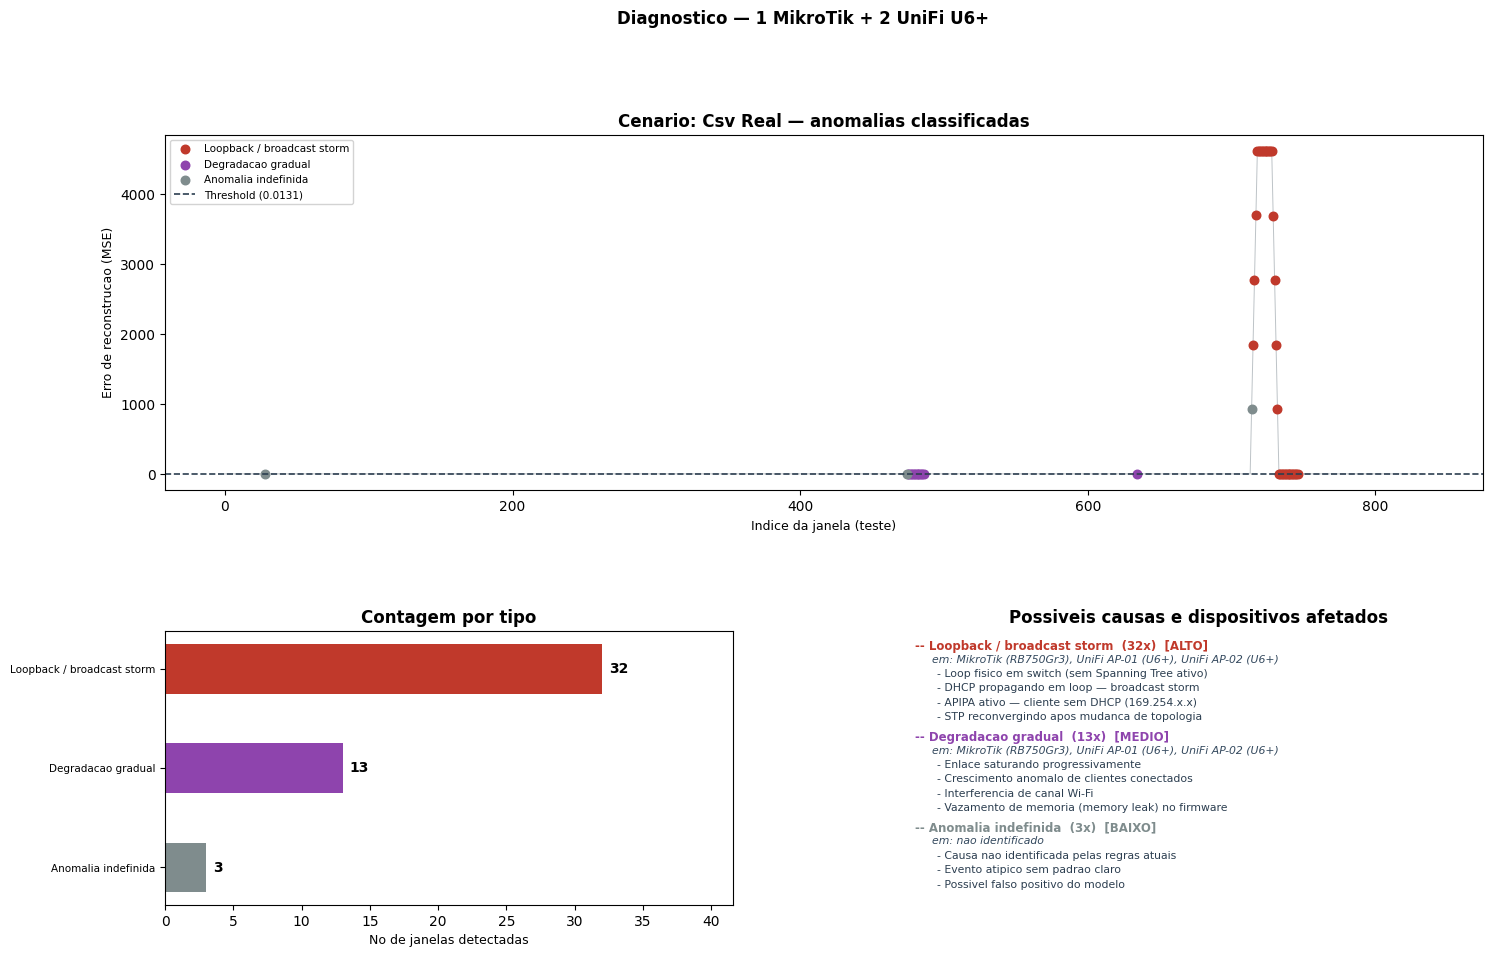

In [185]:
TIPO_COR = {t: d['cor'] for t, d in DIAGNOSTICOS.items()}

fig = plt.figure(figsize=(17, 10))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.3, 1.0], hspace=0.45, wspace=0.32)
ax_ts    = fig.add_subplot(gs[0, :])
ax_bar   = fig.add_subplot(gs[1, 0])
ax_cause = fig.add_subplot(gs[1, 1])

# Serie temporal do erro com scatter por tipo
ax_ts.plot(range(len(err_test_s)), err_test_s, color='#bdc3c7', linewidth=0.7, zorder=1)
for tipo, cor in TIPO_COR.items():
    sub = results_df[results_df['tipo'] == tipo]
    if len(sub):
        ax_ts.scatter(sub['janela_idx'], sub['erro_reconstrucao'],
                      color=cor, s=38, zorder=2, label=tipo)
ax_ts.axhline(threshold, color='#2c3e50', linestyle='--', linewidth=1.2,
              label=f'Threshold ({threshold:.4f})')
ax_ts.set_xlabel('Indice da janela (teste)', fontsize=9)
ax_ts.set_ylabel('Erro de reconstrucao (MSE)', fontsize=9)
ax_ts.set_title(f'Cenario: {nome_cenario.replace("_"," ").title()} — anomalias classificadas',
                fontweight='bold')
ax_ts.legend(loc='upper left', fontsize=7.5, framealpha=0.85)

# Barras de contagem por tipo
tipos_presentes = [t for t in DIAGNOSTICOS if t in results_df['tipo'].values]
contagens = [results_df['tipo'].eq(t).sum() for t in tipos_presentes]
cores     = [TIPO_COR[t] for t in tipos_presentes]
if tipos_presentes:
    bars = ax_bar.barh(tipos_presentes[::-1], contagens[::-1],
                       color=cores[::-1], height=0.5)
    ax_bar.bar_label(bars, padding=5, fontsize=10, fontweight='bold')
    ax_bar.set_xlim(0, max(contagens) * 1.3)
ax_bar.set_xlabel('No de janelas detectadas', fontsize=9)
ax_bar.set_title('Contagem por tipo', fontweight='bold')
ax_bar.tick_params(axis='y', labelsize=7.5)

# Painel de causas + dispositivos afetados
ax_cause.axis('off')
ax_cause.set_title('Possiveis causas e dispositivos afetados', fontweight='bold')

n_linhas = sum(1 + len(DIAGNOSTICOS[t]['causas']) for t in tipos_presentes) + len(tipos_presentes) * 1.2
step = min(0.10, 0.93 / max(n_linhas, 1))

y_pos = 0.97
for tipo in tipos_presentes:
    diag = DIAGNOSTICOS[tipo]
    sub  = results_df[results_df['tipo'] == tipo]
    devs = ', '.join(sorted(set(d.strip() for s in sub['dispositivos'] for d in s.split(','))))

    ax_cause.text(0.0, y_pos, f"-- {tipo}  ({len(sub)}x)  [{diag['severidade']}]",
                  transform=ax_cause.transAxes,
                  fontsize=8.5, fontweight='bold', color=diag['cor'], va='top')
    y_pos -= step
    ax_cause.text(0.03, y_pos, f"em: {devs}",
                  transform=ax_cause.transAxes,
                  fontsize=7.8, color='#34495e', style='italic', va='top')
    y_pos -= step
    for causa in diag['causas']:
        ax_cause.text(0.04, y_pos, f"- {causa}",
                      transform=ax_cause.transAxes,
                      fontsize=7.8, color='#2c3e50', va='top')
        y_pos -= step
    y_pos -= step * 0.3

plt.suptitle(f'Diagnostico — 1 MikroTik + 2 UniFi U6+',
             fontsize=12, fontweight='bold', y=1.005)

# Mostra na tela — salvar e opcional, via botao ao final
plt.show()


In [186]:
# Relatorio
print('=' * 84)
print(f'RELATORIO DE DIAGNOSTICO — cenario: {nome_cenario}')
print('=' * 84)
print(f'\n{"Idx":<8} {"MSE":<14} {"Severidade":<10} {"Tipo":<32} Dispositivos')
print('-' * 84)

for _, row in results_df.iterrows():
    sev = DIAGNOSTICOS[row['tipo']]['severidade']
    print(f"{int(row['janela_idx']):<8} {row['erro_reconstrucao']:<14.5f} {sev:<10} {row['tipo']:<32} {row['dispositivos']}")

print('=' * 84)


print('\n\nINTERPRETACAO POR TIPO\n' + '=' * 84)
contagens = results_df['tipo'].value_counts()
for tipo, n in contagens.items():
    diag = DIAGNOSTICOS[tipo]
    devs = ', '.join(sorted(set(d.strip()
                                 for s in results_df[results_df['tipo']==tipo]['dispositivos']
                                 for d in s.split(','))))
    print(f"\n[{tipo.upper()}]  ({n} ocorrencia(s) — {diag['severidade']})")
    print(f"  Dispositivos afetados: {devs}")
    print(f"  Acao recomendada: {diag['acao']}")


RELATORIO DE DIAGNOSTICO — cenario: csv_real

Idx      MSE            Severidade Tipo                             Dispositivos
------------------------------------------------------------------------------------
28       0.01322        BAIXO      Anomalia indefinida              nao identificado
474      0.04529        BAIXO      Anomalia indefinida              nao identificado
475      0.08254        MEDIO      Degradacao gradual               MikroTik (RB750Gr3), UniFi AP-01 (U6+)
476      0.11975        MEDIO      Degradacao gradual               MikroTik (RB750Gr3), UniFi AP-01 (U6+)
477      0.15497        MEDIO      Degradacao gradual               MikroTik (RB750Gr3), UniFi AP-01 (U6+)
478      0.22686        MEDIO      Degradacao gradual               MikroTik (RB750Gr3)
479      0.24104        MEDIO      Degradacao gradual               MikroTik (RB750Gr3)
480      0.24450        MEDIO      Degradacao gradual               MikroTik (RB750Gr3), UniFi AP-02 (U6+)
481      0.221

## 7. Botão salvar Resultados

In [187]:
import shutil

# Area onde aparecem as mensagens do botao
saida_botao = widgets.Output()

def _empacotar(b):
    with saida_botao:
        clear_output()
        print(f'Empacotando resultados do cenario "{nome_cenario}"...')

        # 1. Salva o grafico de diagnostico
        fig.savefig(f'{RES_DIR}/diagnostico_{nome_cenario}.png',
                    dpi=120, bbox_inches='tight')
        print(f'  [ok] grafico         -> diagnostico_{nome_cenario}.png')

        # 2. Salva a tabela de classificacao
        results_df.to_csv(f'{RES_DIR}/classificacao_{nome_cenario}.csv', index=False)
        print(f'  [ok] classificacao   -> classificacao_{nome_cenario}.csv')

        # 3. Salva o modelo treinado
        model.save(f'{RES_DIR}/modelo_{nome_cenario}.keras')
        print(f'  [ok] modelo          -> modelo_{nome_cenario}.keras')

        # 4. Copia o CSV de origem
        shutil.copy(csv_alvo, f'{RES_DIR}/dados_{nome_cenario}.csv')
        print(f'  [ok] CSV de origem   -> dados_{nome_cenario}.csv')

        # 5. Empacota em ZIP com nome do cenario
        zip_base = f'resultados_{nome_cenario}'
        shutil.make_archive(zip_base, 'zip', '.', RES_DIR)
        zip_path = f'{zip_base}.zip'
        size_kb  = os.path.getsize(zip_path) / 1024
        print(f'\n  [ok] ZIP: {zip_path}  ({size_kb:.1f} KB)')

        # 6. Download no Colab — silencioso fora dele
        try:
            from google.colab import files
            files.download(zip_path)
            print('  Download iniciado.')
        except ImportError:
            print(f'  Arquivo disponivel em ./{zip_path}')

# Botao
btn = widgets.Button(
    description=f'Salvar analise — {nome_cenario}',
    button_style='success',
    tooltip='Empacota grafico, classificacao, modelo e CSV em um ZIP',
    icon='download',
    layout=widgets.Layout(width='380px', height='50px'),
)
btn.on_click(_empacotar)

display(btn, saida_botao)


Button(button_style='success', description='Salvar analise — csv_real', icon='download', layout=Layout(height=…

Output()